# 2D Planar Translunar Trajectory

This notebook builds a **truth simulation** of a spacecraft thrown from Earth toward the Moon: a restricted three-body problem in a Sun-centered inertial plane, integrated with `scipy.integrate.solve_ivp`. There is no Kalman filtering, no synthetic measurements, and no noise here -- just the true trajectory.

## Physical setup

- **Frame and units.** Sun-centered inertial frame, 2D (x, y). Distances in kilometers, time in hours, everywhere except the `launch_speed` parameter (km/s, the conventional unit for injection speeds -- converted to km/hr where it is used).
- **The Sun** sits fixed at the origin.
- **Earth** is *not* integrated: it moves on a prescribed circle of radius 1 AU around the Sun with a 365.25-day period.
- **The Moon** is *not* integrated either: it moves on a prescribed circle of radius 384400 km around the *moving* Earth with a 27.32-day period.
- **The spacecraft** is the only integrated body. Its state is `[x, y, vx, vy]`, and its acceleration is the sum of point-mass, inverse-square gravity from the Sun, Earth, and the Moon. No thrust after launch, no drag.

## "Thrown from Earth"

The spacecraft starts at a fixed altitude above Earth's surface, at a configurable angular position around Earth. Its initial velocity is **Earth's own heliocentric orbital velocity** plus a **launch velocity increment** -- the geocentric speed a translunar-injection (TLI) burn would provide, added in the local (radial / tangential) frame defined by the launch point itself. `launch_speed` and `launch_angle` are the two parameters hand-tuned below to steer this near-escape trajectory into a close flyby of the Moon.

## Equations of motion

For a spacecraft at position $\mathbf{s} = (x, y)$, with the Sun fixed at the origin and Earth/Moon at their prescribed positions $\mathbf{r}_E(t)$, $\mathbf{r}_M(t)$, the acceleration is the sum of three point-mass gravitational pulls:

$$
\ddot{\mathbf{s}} = GM_{sun}\,\frac{-\mathbf{s}}{|\mathbf{s}|^3} \;+\; GM_{earth}\,\frac{\mathbf{r}_E(t) - \mathbf{s}}{|\mathbf{r}_E(t) - \mathbf{s}|^3} \;+\; GM_{moon}\,\frac{\mathbf{r}_M(t) - \mathbf{s}}{|\mathbf{r}_M(t) - \mathbf{s}|^3}
$$

As a first-order system in the state $(x, y, v_x, v_y)$, this is exactly the form `solve_ivp` expects: a function $f(t, \mathbf{state})$ returning $\dot{\mathbf{state}}$.

## Parameters

All physical constants, prescribed-orbit parameters, launch geometry, and integration settings are gathered here.

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.collections import LineCollection
from scipy.integrate import solve_ivp

# --- Gravitational parameters (GM = G * mass) ---
# Standard values are conventionally tabulated in km^3/s^2. Since this notebook
# works in hours everywhere, we convert once here: 1 hour = 3600 s, so
#   GM [km^3/hr^2] = GM [km^3/s^2] * (3600 s/hr)^2
seconds_per_hour = 3600.0
hour_conversion_factor = seconds_per_hour ** 2   # multiply km^3/s^2 values by this to get km^3/hr^2

GM_sun_km3_s2 = 1.32712440018e11   # Sun,   standard gravitational parameter [km^3/s^2]
GM_earth_km3_s2 = 3.986004418e5    # Earth, standard gravitational parameter [km^3/s^2]
GM_moon_km3_s2 = 4.9028e3          # Moon,  standard gravitational parameter [km^3/s^2]

GM_sun = GM_sun_km3_s2 * hour_conversion_factor      # [km^3/hr^2]
GM_earth = GM_earth_km3_s2 * hour_conversion_factor  # [km^3/hr^2]
GM_moon = GM_moon_km3_s2 * hour_conversion_factor    # [km^3/hr^2]

# --- Body sizes, used for the crash events and for drawing Earth to scale ---
earth_radius = 6378.0   # Earth's mean radius [km]
moon_radius = 1737.0    # Moon's mean radius [km]

# --- Earth's prescribed circular heliocentric orbit ---
earth_orbit_radius = 149_597_870.7   # 1 AU [km]
earth_orbit_period = 365.25 * 24.0   # sidereal-ish year, expressed in hours [hr]
earth_orbit_angular_rate = 2.0 * np.pi / earth_orbit_period   # [rad/hr]
earth_initial_phase = 0.0   # Earth's angular position around the Sun at t=0 [rad]; configurable

# --- Moon's prescribed circular orbit around the (moving) Earth ---
moon_orbit_radius = 384_400.0        # mean Earth-Moon distance [km]
moon_orbit_period = 27.32 * 24.0     # sidereal month, expressed in hours [hr]
moon_orbit_angular_rate = 2.0 * np.pi / moon_orbit_period   # [rad/hr]
moon_initial_phase = np.radians(144.5)   # Moon's angular position around Earth at t=0 [rad]; configurable
                                          # (chosen, along with launch_speed/launch_angle below, so the
                                          # Moon is where the spacecraft can reach it within the 6-day run)

# --- Launch geometry: where around Earth the spacecraft starts ---
launch_altitude = 300.0                              # altitude above Earth's surface at launch [km]
launch_radius = earth_radius + launch_altitude        # distance from Earth's center at launch [km]
launch_position_angle = 0.0   # angular position of the launch point around Earth [rad], configurable;
                               # measured counterclockwise from the inertial +x axis

# --- Launch velocity: Earth's orbital velocity PLUS a launch increment ---
# The launch increment is added in the *local* Earth-centered frame defined
# by the launch point itself: radial_hat points from Earth's center straight
# out through the launch point, and tangential_hat is radial_hat rotated 90
# degrees counterclockwise (the local "horizontal" direction). launch_angle
# is measured from tangential_hat toward radial_hat, so launch_angle = 0 is
# a purely tangential ("horizontal") burn and launch_angle = 90 deg is a
# purely radial ("straight up") burn.
#
# These two parameters are the ones meant to be hand-tuned to achieve a
# near-Moon flyby: launch_speed sets how close to Earth's local escape speed
# (~10.92 km/s at this altitude) the injection is -- and hence how far out
# the resulting long ellipse's apogee reaches -- while launch_angle tilts
# the initial velocity slightly off-horizontal, which rotates the resulting
# orbit's line of apsides and shifts where (in angle) the trajectory crosses
# the Moon's distance. Small changes in either one make a large difference
# far downrange, so they are tuned by trial and error while watching the
# closest-approach printout below.
launch_speed = 10.9               # geocentric launch speed increment [km/s] (see markdown above)
launch_angle = np.radians(-3.5)   # direction of the launch increment in the local frame [rad]

# --- Simulation time settings ---
simulation_duration_days = 20.0                          # total simulated time span [days]
simulation_duration = simulation_duration_days * 24.0   # [hr]
num_output_points = 2000                                # number of points in the uniform output time grid

## Prescribed motion of Earth and the Moon

Earth's circular heliocentric motion is
$$
\mathbf{r}_E(t) = R_E\big(\cos(\phi_E + \omega_E t),\ \sin(\phi_E + \omega_E t)\big), \qquad \omega_E = \frac{2\pi}{T_E}
$$
Differentiating gives Earth's orbital velocity analytically:
$$
\dot{\mathbf{r}}_E(t) = R_E \omega_E\big(-\sin(\phi_E + \omega_E t),\ \cos(\phi_E + \omega_E t)\big)
$$
The Moon's position is Earth's (moving) position plus its own small circle around Earth:
$$
\mathbf{r}_M(t) = \mathbf{r}_E(t) + R_M\big(\cos(\phi_M + \omega_M t),\ \sin(\phi_M + \omega_M t)\big)
$$
Neither Earth nor the Moon is integrated -- both are evaluated analytically at whatever time the spacecraft's equations of motion need them.

In [2]:
def earth_position(t):
    """
    Earth's position (x, y) [km] in the Sun-centered inertial frame at
    time(s) t [hr], on its prescribed circular heliocentric orbit.
    """
    angle = earth_initial_phase + earth_orbit_angular_rate * t
    return earth_orbit_radius * np.cos(angle), earth_orbit_radius * np.sin(angle)


def earth_velocity(t):
    """
    Earth's velocity (vx, vy) [km/hr] in the Sun-centered inertial frame at
    time(s) t [hr]. Obtained by differentiating the circular motion
    x = R*cos(phase0 + omega*t), y = R*sin(phase0 + omega*t) with respect
    to time:
        vx = -R*omega*sin(phase0 + omega*t)
        vy =  R*omega*cos(phase0 + omega*t)
    """
    angle = earth_initial_phase + earth_orbit_angular_rate * t
    return (-earth_orbit_radius * earth_orbit_angular_rate * np.sin(angle),
            earth_orbit_radius * earth_orbit_angular_rate * np.cos(angle))


def moon_position(t):
    """
    Moon's position (x, y) [km] in the Sun-centered inertial frame at
    time(s) t [hr]: Earth's (moving) position plus a small circle of radius
    moon_orbit_radius around it, on the Moon's prescribed orbit.
    """
    earth_x, earth_y = earth_position(t)
    angle = moon_initial_phase + moon_orbit_angular_rate * t
    return earth_x + moon_orbit_radius * np.cos(angle), earth_y + moon_orbit_radius * np.sin(angle)

## Initial state of the spacecraft ("thrown from Earth" at t = 0)

The spacecraft starts at altitude `launch_altitude` above Earth's surface, at angular position `launch_position_angle` around Earth. Its initial position and velocity are built in the local Earth-centered (radial, tangential) frame defined by that launch point, then made absolute by adding Earth's own position/velocity at t = 0.

In [3]:
# Local Earth-centered frame at the launch point (see comment above
# launch_angle): radial_hat points from Earth's center through the launch
# point, tangential_hat is radial_hat rotated 90 degrees counterclockwise.
radial_hat = np.array([np.cos(launch_position_angle), np.sin(launch_position_angle)])
tangential_hat = np.array([-np.sin(launch_position_angle), np.cos(launch_position_angle)])

# Spacecraft's position relative to Earth's center at launch, then made
# absolute (Sun-frame) by adding Earth's own position at t=0.
launch_point_relative = launch_radius * radial_hat
earth_pos_0 = np.array(earth_position(0.0))
spacecraft_initial_position = earth_pos_0 + launch_point_relative

# Launch velocity increment, expressed in the local (tangential, radial)
# frame, then converted from km/s to km/hr to match this notebook's units.
launch_speed_km_per_hr = launch_speed * seconds_per_hour
launch_velocity_increment = launch_speed_km_per_hr * (
    np.cos(launch_angle) * tangential_hat + np.sin(launch_angle) * radial_hat
)

# Total initial velocity = Earth's heliocentric orbital velocity + the
# launch increment (the spacecraft's velocity relative to Earth).
earth_vel_0 = np.array(earth_velocity(0.0))
spacecraft_initial_velocity = earth_vel_0 + launch_velocity_increment

initial_state = [
    spacecraft_initial_position[0], spacecraft_initial_position[1],
    spacecraft_initial_velocity[0], spacecraft_initial_velocity[1],
]
print(f"Initial position (Sun frame): {spacecraft_initial_position} km")
print(f"Initial velocity (Sun frame): {spacecraft_initial_velocity} km/hr")

Initial position (Sun frame): [1.49604549e+08 0.00000000e+00] km
Initial velocity (Sun frame): [ -2395.54469135 146393.7252062 ] km/hr


## Equations of motion function

`spacecraft_equations` implements the three-body acceleration derived above, in the exact form `solve_ivp` requires: a function `f(t, state)` returning `d(state)/dt`.

In [4]:
def spacecraft_equations(t, state):
    """
    Compute the time derivative of the spacecraft state [x, y, vx, vy].

    The spacecraft's acceleration is the sum of three point-mass,
    inverse-square gravitational pulls: from the Sun (fixed at the
    origin), from Earth (at its prescribed position at time t), and from
    the Moon (at its prescribed position at time t). For a body at
    position P exerting gravity on the spacecraft at position S, the
    acceleration contribution is GM * (P - S) / |P - S|^3 -- i.e. pointing
    from the spacecraft toward that body, scaled by inverse-square
    distance.
    """
    x, y, vx, vy = state

    earth_x, earth_y = earth_position(t)
    moon_x, moon_y = moon_position(t)

    # Vector from the spacecraft to each attracting body, and the distance
    # to each (the Sun sits fixed at the origin, so its vector is just
    # (0,0) - (x,y)).
    dx_sun, dy_sun = -x, -y
    r_sun = np.hypot(dx_sun, dy_sun)

    dx_earth, dy_earth = earth_x - x, earth_y - y
    r_earth = np.hypot(dx_earth, dy_earth)

    dx_moon, dy_moon = moon_x - x, moon_y - y
    r_moon = np.hypot(dx_moon, dy_moon)

    ax = (GM_sun * dx_sun / r_sun ** 3
          + GM_earth * dx_earth / r_earth ** 3
          + GM_moon * dx_moon / r_moon ** 3)
    ay = (GM_sun * dy_sun / r_sun ** 3
          + GM_earth * dy_earth / r_earth ** 3
          + GM_moon * dy_moon / r_moon ** 3)

    return [vx, vy, ax, ay]

## Terminal events: crash into Earth or the Moon

Two terminal events stop the integration early: one fires when the spacecraft's distance to Earth's center drops to Earth's radius (a crash into Earth), the other when its distance to the Moon's center drops to the Moon's radius (a crash into the Moon). Both use `direction = -1` so they only trigger while approaching (distance decreasing through zero), not departing.

In [5]:
def earth_crash_event(t, state):
    """Zero when the spacecraft's distance to Earth's center equals Earth's radius."""
    x, y = state[0], state[1]
    earth_x, earth_y = earth_position(t)
    return np.hypot(x - earth_x, y - earth_y) - earth_radius


earth_crash_event.terminal = True   # stop the integration when this event fires
earth_crash_event.direction = -1    # only trigger while distance is decreasing (approaching, not departing)


def moon_crash_event(t, state):
    """Zero when the spacecraft's distance to the Moon's center equals the Moon's radius."""
    x, y = state[0], state[1]
    moon_x, moon_y = moon_position(t)
    return np.hypot(x - moon_x, y - moon_y) - moon_radius


moon_crash_event.terminal = True
moon_crash_event.direction = -1

## Running the simulation

Integrate the spacecraft's equations of motion over the full 6-day window with `solve_ivp`, using `method="DOP853"` and tight tolerances (`rtol = atol = 1e-10`), with dense output evaluated on a uniform grid of 2000 points, and the two crash events armed as terminal conditions.

In [6]:
output_times = np.linspace(0.0, simulation_duration, num_output_points)

solution = solve_ivp(
    fun=spacecraft_equations,
    t_span=(0.0, simulation_duration),
    y0=initial_state,
    t_eval=output_times,
    method="DOP853",     # high-order explicit Runge-Kutta, good for smooth, high-accuracy orbital integration
    rtol=1e-10,
    atol=1e-10,
    events=[earth_crash_event, moon_crash_event],
)

time = solution.t
spacecraft_x = solution.y[0]
spacecraft_y = solution.y[1]
spacecraft_vx = solution.y[2]
spacecraft_vy = solution.y[3]

earth_traj_x, earth_traj_y = earth_position(time)
moon_traj_x, moon_traj_y = moon_position(time)

if solution.t_events[0].size > 0:
    print(f"*** Spacecraft crashed into Earth at t = {solution.t_events[0][0]:.3f} hr ***")
if solution.t_events[1].size > 0:
    print(f"*** Spacecraft crashed into the Moon at t = {solution.t_events[1][0]:.3f} hr ***")

## Closest approach to the Moon

For hand-tuning `launch_speed` and `launch_angle`, compute and print the closest distance the spacecraft comes to the Moon's center over the run, and the time at which it occurs.

In [7]:
distance_to_moon = np.hypot(spacecraft_x - moon_traj_x, spacecraft_y - moon_traj_y)
closest_index = np.argmin(distance_to_moon)
closest_approach_distance = distance_to_moon[closest_index]
closest_approach_time = time[closest_index]

print(f"Closest approach to the Moon: {closest_approach_distance:.1f} km "
      f"at t = {closest_approach_time:.3f} hr ({closest_approach_time / 24.0:.3f} days)")

Closest approach to the Moon: 3121.0 km at t = 53.883 hr (2.245 days)


## Validation: three-body specific-energy drift

The spacecraft's specific (per unit mass) orbital energy relative to the Sun, including the gravitational potential of all three attracting bodies at each instant:

$$
E(t) = \tfrac{1}{2}|\mathbf v|^2 - \frac{GM_{sun}}{r_{sun}} - \frac{GM_{earth}}{r_{earth}} - \frac{GM_{moon}}{r_{moon}}
$$

Because Earth and the Moon are moving (not fixed) sources, $E(t)$ is **not** a true constant of motion here -- it will drift somewhat for genuine physical reasons (especially during the close lunar approach), on top of any numerical integration error. Still, since the Sun's potential dominates and Earth/Moon are comparatively small, gradual perturbations away from a close encounter, a suspiciously large or erratic drift outside of the flyby itself would be a useful red flag for integration trouble.

In [8]:
r_sun_arr = np.hypot(spacecraft_x, spacecraft_y)
r_earth_arr = np.hypot(spacecraft_x - earth_traj_x, spacecraft_y - earth_traj_y)
r_moon_arr = distance_to_moon

specific_energy = (0.5 * (spacecraft_vx ** 2 + spacecraft_vy ** 2)
                   - GM_sun / r_sun_arr
                   - GM_earth / r_earth_arr
                   - GM_moon / r_moon_arr)

relative_energy_drift = np.abs((specific_energy - specific_energy[0]) / specific_energy[0])
print(f"Max relative three-body specific-energy drift over the run: {np.max(relative_energy_drift):.3e}")

Max relative three-body specific-energy drift over the run: 3.018e+00


## Plots

Three views of the simulation:
1. **Sun-frame overview** -- full trajectories of Earth, Moon, and the spacecraft.
2. **Earth-centered view** (the main plot) -- spacecraft and Moon positions with Earth's position subtracted out, Earth drawn to scale, Moon's orbit circle shown for reference.
3. **Distance to the Moon vs. time** -- log scale, with the closest approach marked.

### 1. Sun-frame overview

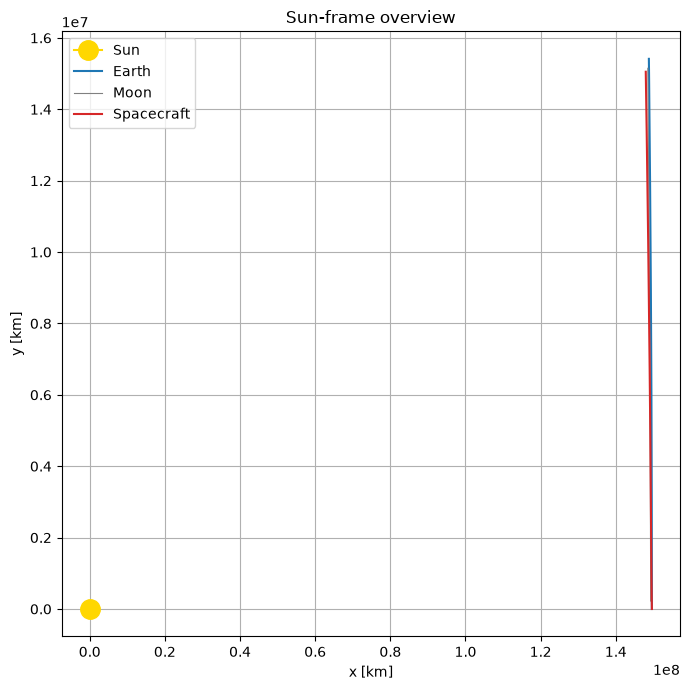

In [9]:
figure1, ax1 = plt.subplots(figsize=(7, 7))
ax1.plot(0, 0, marker="o", color="gold", markersize=14, label="Sun")
ax1.plot(earth_traj_x, earth_traj_y, color="tab:blue", label="Earth")
ax1.plot(moon_traj_x, moon_traj_y, color="gray", linewidth=0.8, label="Moon")
ax1.plot(spacecraft_x, spacecraft_y, color="tab:red", label="Spacecraft")
ax1.set_xlabel("x [km]")
ax1.set_ylabel("y [km]")
ax1.set_title("Sun-frame overview")
# ax1.set_aspect("equal")
ax1.legend()
ax1.grid(True)
figure1.tight_layout()
plt.show()

### 2. Earth-centered view (main plot)

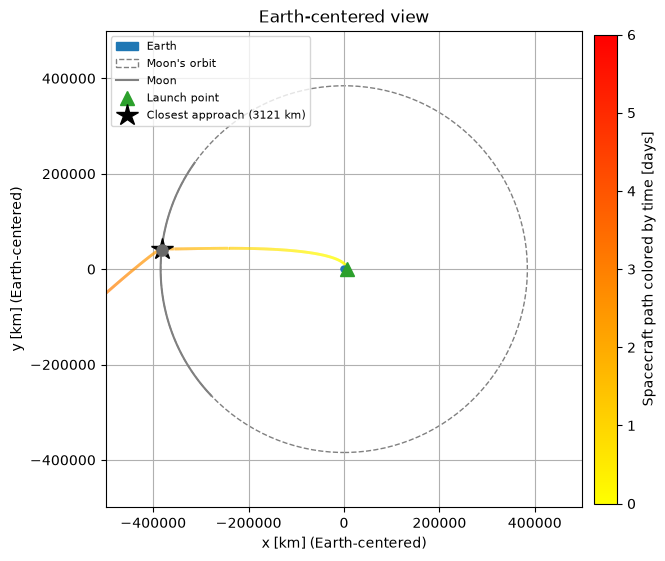

In [10]:
spacecraft_rel_x = spacecraft_x - earth_traj_x
spacecraft_rel_y = spacecraft_y - earth_traj_y
moon_rel_x = moon_traj_x - earth_traj_x
moon_rel_y = moon_traj_y - earth_traj_y

figure2, ax2 = plt.subplots(figsize=(7, 7))

# Earth, drawn to scale as a filled circle at the origin of this frame.
earth_circle = Circle((0, 0), earth_radius, color="tab:blue", label="Earth", zorder=3)
ax2.add_patch(earth_circle)

# Moon's prescribed circular orbit around Earth, for reference.
moon_orbit_circle = Circle((0, 0), moon_orbit_radius, color="gray", fill=False,
                            linestyle="--", linewidth=1.0, label="Moon's orbit")
ax2.add_patch(moon_orbit_circle)

ax2.plot(moon_rel_x, moon_rel_y, color="gray", linewidth=1.5, label="Moon")

# Color the spacecraft's Earth-relative path by elapsed time. After the lunar
# flyby it heads back out well past the Moon's orbit at high (roughly
# constant) speed, so a plain single-color line looks like a meaningless
# squiggle near Earth -- coloring by time makes the direction of travel and
# the very different speeds of the outbound coast vs. the flyby itself clear.
spacecraft_points = np.array([spacecraft_rel_x, spacecraft_rel_y]).T.reshape(-1, 1, 2)
spacecraft_segments = np.concatenate([spacecraft_points[:-1], spacecraft_points[1:]], axis=1)
spacecraft_line_collection = LineCollection(
    spacecraft_segments, cmap="autumn_r", norm=plt.Normalize(time[0] / 24.0, time[-1] / 24.0)
)
spacecraft_line_collection.set_array(time[:-1] / 24.0)
spacecraft_line_collection.set_linewidth(2.0)
ax2.add_collection(spacecraft_line_collection)
colorbar = figure2.colorbar(spacecraft_line_collection, ax=ax2, shrink=0.7, pad=0.02)
colorbar.set_label("Spacecraft path colored by time [days]")

ax2.plot(spacecraft_rel_x[0], spacecraft_rel_y[0], marker="^", color="tab:green", markersize=10,
         linestyle="None", zorder=4, label="Launch point")

# Mark the moment of closest lunar approach on both paths, joined by a thin
# dotted line, so the actual miss distance is visually obvious rather than
# having to be read off the separate distance-vs-time plot below.
ax2.plot(spacecraft_rel_x[closest_index], spacecraft_rel_y[closest_index], marker="*",
         color="black", markersize=16, linestyle="None", zorder=5,
         label=f"Closest approach ({closest_approach_distance:.0f} km)")
ax2.plot(moon_rel_x[closest_index], moon_rel_y[closest_index], marker="o", color="dimgray",
         markersize=8, linestyle="None", zorder=5)
ax2.plot([spacecraft_rel_x[closest_index], moon_rel_x[closest_index]],
         [spacecraft_rel_y[closest_index], moon_rel_y[closest_index]],
         color="black", linestyle=":", linewidth=1.0, zorder=4)

ax2.set_xlabel("x [km] (Earth-centered)")
ax2.set_ylabel("y [km] (Earth-centered)")
ax2.set_title("Earth-centered view")
ax2.set_aspect("equal")

# Zoom to the scale of the Earth-Moon system. Letting the axes autoscale to
# the full trajectory (including the post-flyby outbound leg, which runs out
# to roughly twice the Moon's orbital radius) would squash the launch,
# coast, and flyby -- the actually interesting part -- into an unreadable
# smudge in a corner. The trajectory is simply allowed to run off the edge
# of this zoomed frame.
zoom_radius = 1.3 * moon_orbit_radius
ax2.set_xlim(-zoom_radius, zoom_radius)
ax2.set_ylim(-zoom_radius, zoom_radius)

ax2.legend(loc="upper left", fontsize=8)
ax2.grid(True)
figure2.tight_layout()
plt.show()

### 3. Distance from spacecraft to Moon center vs. time

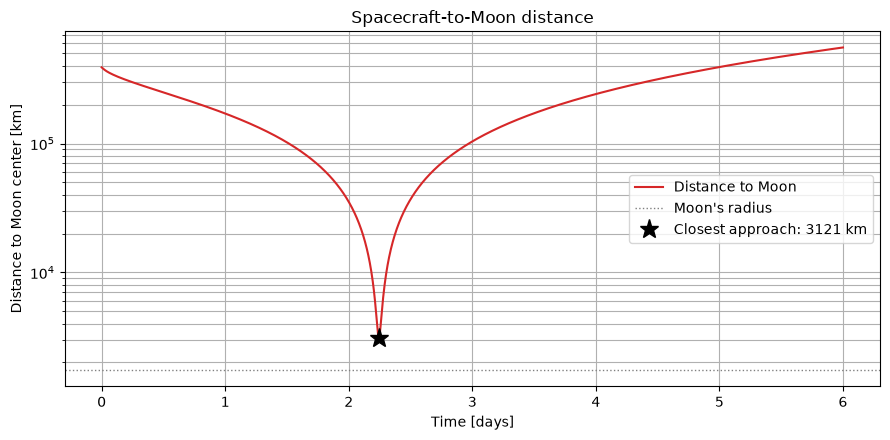

In [11]:
figure3, ax3 = plt.subplots(figsize=(9, 4.5))
ax3.plot(time / 24.0, distance_to_moon, color="tab:red", label="Distance to Moon")
ax3.axhline(moon_radius, color="gray", linestyle=":", linewidth=1.0, label="Moon's radius")
ax3.plot(closest_approach_time / 24.0, closest_approach_distance, marker="*", color="black",
         markersize=14, linestyle="None",
         label=f"Closest approach: {closest_approach_distance:.0f} km")
ax3.set_yscale("log")
ax3.set_xlabel("Time [days]")
ax3.set_ylabel("Distance to Moon center [km]")
ax3.set_title("Spacecraft-to-Moon distance")
ax3.legend()
ax3.grid(True, which="both")
figure3.tight_layout()
plt.show()

## Interactive tuning: adjust launch parameters and re-plot

Drag the `launch speed`, `launch angle`, and `duration` sliders below, then click **Update trajectory** to re-integrate and redraw the Earth-centered view -- without needing to re-run the rest of the notebook. This is a quick way to hand-tune toward a closer (or more distant) lunar flyby, or to simulate a longer or shorter time span.

In [16]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- Interactive widgets for the two tuning parameters ---
speed_slider = widgets.FloatSlider(
    value=launch_speed, min=10.5, max=11.3, step=0.005,
    description="Launch speed [km/s]:", style={"description_width": "150px"},
    layout=widgets.Layout(width="500px"), readout_format=".3f",
)
angle_slider = widgets.FloatSlider(
    value=np.degrees(launch_angle), min=-15.0, max=15.0, step=0.1,
    description="Launch angle [deg]:", style={"description_width": "150px"},
    layout=widgets.Layout(width="500px"), readout_format=".2f",
)
duration_slider = widgets.FloatSlider(
    value=simulation_duration_days, min=1.0, max=20.0, step=0.5,
    description="Duration [days]:", style={"description_width": "150px"},
    layout=widgets.Layout(width="500px"), readout_format=".1f",
)
update_button = widgets.Button(description="Update trajectory", button_style="primary")
output_area = widgets.Output()


def run_trial_and_plot(_=None):
    """Re-integrate with the current slider values and redraw the Earth-centered view."""
    trial_launch_speed = speed_slider.value
    trial_launch_angle = np.radians(angle_slider.value)
    trial_simulation_duration = duration_slider.value * 24.0   # [hr]
    trial_output_times = np.linspace(0.0, trial_simulation_duration, num_output_points)

    # Rebuild the initial state with the trial launch parameters. Everything
    # else (launch point, launch altitude, Earth/Moon phasing) stays the
    # same as the main run above -- only the launch speed/angle/duration change.
    trial_speed_km_per_hr = trial_launch_speed * seconds_per_hour
    trial_velocity_increment = trial_speed_km_per_hr * (
        np.cos(trial_launch_angle) * tangential_hat + np.sin(trial_launch_angle) * radial_hat
    )
    trial_initial_velocity = earth_vel_0 + trial_velocity_increment
    trial_initial_state = [
        spacecraft_initial_position[0], spacecraft_initial_position[1],
        trial_initial_velocity[0], trial_initial_velocity[1],
    ]

    # Re-integrate with the trial parameters, same settings as the main run.
    trial_solution = solve_ivp(
        fun=spacecraft_equations,
        t_span=(0.0, trial_simulation_duration),
        y0=trial_initial_state,
        t_eval=trial_output_times,
        method="DOP853",
        rtol=1e-10,
        atol=1e-10,
        events=[earth_crash_event, moon_crash_event],
    )

    trial_time = trial_solution.t
    trial_x, trial_y = trial_solution.y[0], trial_solution.y[1]
    trial_earth_x, trial_earth_y = earth_position(trial_time)
    trial_moon_x, trial_moon_y = moon_position(trial_time)

    trial_distance_to_moon = np.hypot(trial_x - trial_moon_x, trial_y - trial_moon_y)
    trial_closest_index = np.argmin(trial_distance_to_moon)
    trial_closest_distance = trial_distance_to_moon[trial_closest_index]
    trial_closest_time = trial_time[trial_closest_index]

    # Earth-centered relative positions, same style as the main Earth-centered plot.
    trial_rel_x = trial_x - trial_earth_x
    trial_rel_y = trial_y - trial_earth_y
    trial_moon_rel_x = trial_moon_x - trial_earth_x
    trial_moon_rel_y = trial_moon_y - trial_earth_y

    with output_area:
        clear_output(wait=True)

        if trial_solution.t_events[0].size > 0:
            print(f"*** Trial trajectory crashed into Earth at t = {trial_solution.t_events[0][0]:.3f} hr ***")
        if trial_solution.t_events[1].size > 0:
            print(f"*** Trial trajectory crashed into the Moon at t = {trial_solution.t_events[1][0]:.3f} hr ***")
        print(f"Closest approach to the Moon: {trial_closest_distance:.1f} km "
              f"at t = {trial_closest_time:.3f} hr ({trial_closest_time / 24.0:.3f} days)")

        trial_figure, trial_ax = plt.subplots(figsize=(7, 7))

        trial_earth_circle = Circle((0, 0), earth_radius, color="tab:blue", label="Earth", zorder=3)
        trial_ax.add_patch(trial_earth_circle)
        trial_moon_orbit_circle = Circle((0, 0), moon_orbit_radius, color="gray", fill=False,
                                          linestyle="--", linewidth=1.0, label="Moon's orbit")
        trial_ax.add_patch(trial_moon_orbit_circle)

        trial_ax.plot(trial_moon_rel_x, trial_moon_rel_y, color="gray", linewidth=1.5, label="Moon")

        # Color the spacecraft path by elapsed time, same as the main plot.
        trial_points = np.array([trial_rel_x, trial_rel_y]).T.reshape(-1, 1, 2)
        trial_segments = np.concatenate([trial_points[:-1], trial_points[1:]], axis=1)
        trial_line_collection = LineCollection(
            trial_segments, cmap="autumn_r", norm=plt.Normalize(trial_time[0] / 24.0, trial_time[-1] / 24.0)
        )
        trial_line_collection.set_array(trial_time[:-1] / 24.0)
        trial_line_collection.set_linewidth(2.0)
        trial_ax.add_collection(trial_line_collection)
        trial_colorbar = trial_figure.colorbar(trial_line_collection, ax=trial_ax, shrink=0.7, pad=0.02)
        trial_colorbar.set_label("Spacecraft path colored by time [days]")

        trial_ax.plot(trial_rel_x[0], trial_rel_y[0], marker="^", color="tab:green", markersize=10,
                      linestyle="None", zorder=4, label="Launch point")
        trial_ax.plot(trial_rel_x[trial_closest_index], trial_rel_y[trial_closest_index], marker="*",
                      color="black", markersize=16, linestyle="None", zorder=5,
                      label=f"Closest approach ({trial_closest_distance:.0f} km)")
        trial_ax.plot(trial_moon_rel_x[trial_closest_index], trial_moon_rel_y[trial_closest_index],
                      marker="o", color="dimgray", markersize=8, linestyle="None", zorder=5)
        trial_ax.plot([trial_rel_x[trial_closest_index], trial_moon_rel_x[trial_closest_index]],
                      [trial_rel_y[trial_closest_index], trial_moon_rel_y[trial_closest_index]],
                      color="black", linestyle=":", linewidth=1.0, zorder=4)

        trial_ax.set_xlabel("x [km] (Earth-centered)")
        trial_ax.set_ylabel("y [km] (Earth-centered)")
        trial_ax.set_title(f"Earth-centered view (trial: speed={trial_launch_speed:.3f} km/s, "
                            f"angle={np.degrees(trial_launch_angle):.2f} deg, "
                            f"duration={duration_slider.value:.1f} days)")
        trial_ax.set_aspect("equal")

        trial_zoom_radius = 1.3 * moon_orbit_radius
        trial_ax.set_xlim(-trial_zoom_radius, trial_zoom_radius)
        trial_ax.set_ylim(-trial_zoom_radius, trial_zoom_radius)

        trial_ax.legend(loc="upper left", fontsize=8)
        trial_ax.grid(True)
        trial_figure.tight_layout()
        plt.show()


update_button.on_click(run_trial_and_plot)
display(widgets.VBox([speed_slider, angle_slider, duration_slider, update_button, output_area]))
run_trial_and_plot()   # draw once with the initial slider values